## Practical: LIME basics

Welcome to the first practical. This will take you through the basics of using `lime`. We'll be using a larger dataset for the second practical, but for ease of visualisation, we'll be using a simple `sklearn` dataset for this practical.

Let's begin by importing `lime`, and one of its sub-libraries, `lime-tabular`. As the name suggests, this sub-library is aimed towards tabular data: we'll be using a continuous dataset, which can be treated as tabular for the purposes of `lime`.

In [1]:
import lime
import lime.lime_tabular

We should also import a bunch of useful processing and pre-processing libraries. Most of these you should recognise; `pandas` streamlines data handling, `numpy` is a linear algebra library, and `sklearn`, or 'sci-kit learn' is python's most regularly used data analysis/machine learning library. `matplotlib` makes plots. 

In [ ]:
import pandas as pd
import numpy as np
import sklearn
import sklearn.datasets, sklearn.ensemble
import matplotlib.pyplot as plt
from matplotlib import cm

We're also going to want to plot in the notebook, and make the plots nice and large.

In [5]:
%matplotlib inline
plt.rcParams['figure.figsize'] = [12, 8]


First of all, our data. We'll be using the `halfmoons` dataset, which `sklearn.datasets.make_moons()` generates. Each data point $i$ consists of a real vector of length two, $[x_{i1}, x_{i2}]$, and a class, $y_i, y \in \{0,1\}$

**Q1.** Generate a dataset of 10,000 data points. You'll want to use the `n_samples` and `noise` parameters. I recommend a noise value of 0.2, but feel free to experiment. 

In [6]:
#Add your code here..
X, y  = sklearn.datasets.make_moons(n_samples=10000, noise= 0.2)


**Q2.** Plot the first 100 points. Make sure to colour the two classes differently.

(**Hint**: `plt.scatter(x_val,y_val)` should get you started)

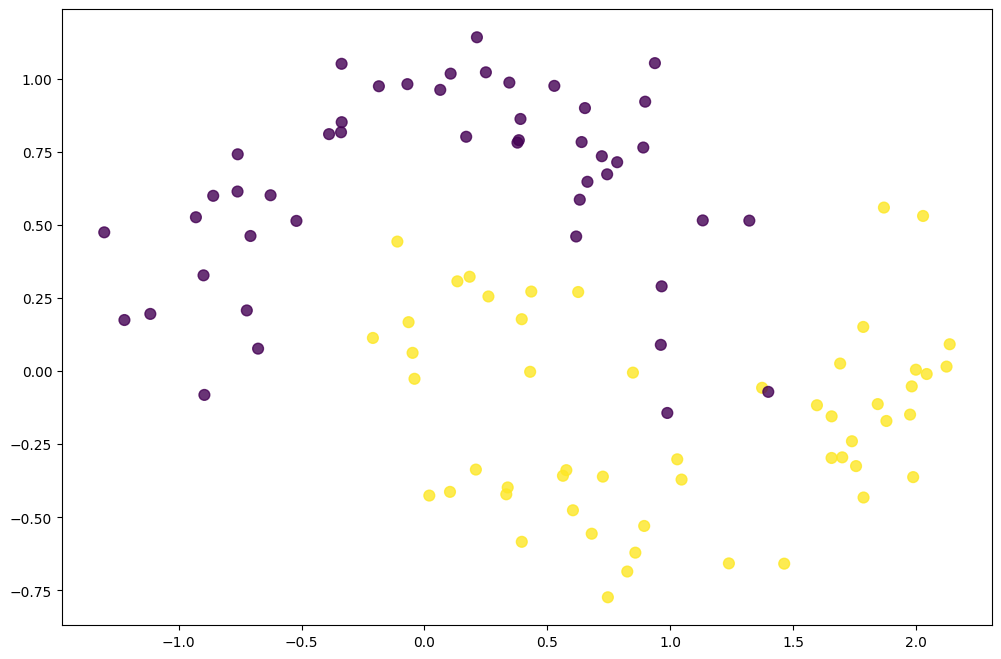

In [7]:
#Add your code here..
col = y[0:100]
z = X[0:100,:]

plt.scatter(
  x=z[:, 0],
  y=z[:, 1],
  c=col,
  cmap="viridis",
  alpha=0.8,
  s=60
);


**Things to think about**: how well do you think LIME is going to do with this dataset? Are there any points of those you've plotted where you think LIME's explanation might not be that informative?

Now let's simulate our black box model. For this, we're going to use a random forest with 200 trees. To get an idea of how well our random forest does on the data, we should split the dataset into a test set and a training set (we should **always** do this for any ML task, unless we have an extremely good reason not to).

In [8]:
train, test, labels_train, labels_test = sklearn.model_selection.train_test_split(X, y, test_size=0.20)

We intialise the classifier as follows:

In [9]:
clf = sklearn.ensemble.RandomForestClassifier(n_estimators=200)

This creates an instance of the classifier. As with most sklearn models it has a `.fit()` method and a `.predict()` method.

**Q3.** Remembering to keep your `train` and `test` separate, fit the classifier to the data.

In [10]:
#Add your code here..
clf.fit(train, labels_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

**Q4.** Now find the precision, recall and f-score of your trained classifier. 

(**Hint**: `sklearn` has a couple of useful functions; `sklearn.metrics.accuracy_score()`, and `sklearn.metrics.classification_report()` are both quick to use)

In [11]:
#Add your code here..
print(sklearn.metrics.accuracy_score(labels_test, clf.predict(test)))
print(sklearn.metrics.classification_report(labels_test, clf.predict(test)))


0.9705
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       995
           1       0.97      0.97      0.97      1005

    accuracy                           0.97      2000
   macro avg       0.97      0.97      0.97      2000
weighted avg       0.97      0.97      0.97      2000



Hopefully, your random forest does pretty well on the half-moons dataset. It should: this isn't a complex dataset. My model gets an F1 score of 0.97; you should expect to be in this sort of range. 

**A question to consider**: if the black box model performs poorly on the dataset of interest, are the explanations less or more useful? What does it depend upon?

**Q5.** Now we have the black box model, we need a point of interest. From the first 100 data points, pick a point of interest, and plot its location relative to the other 100 points.

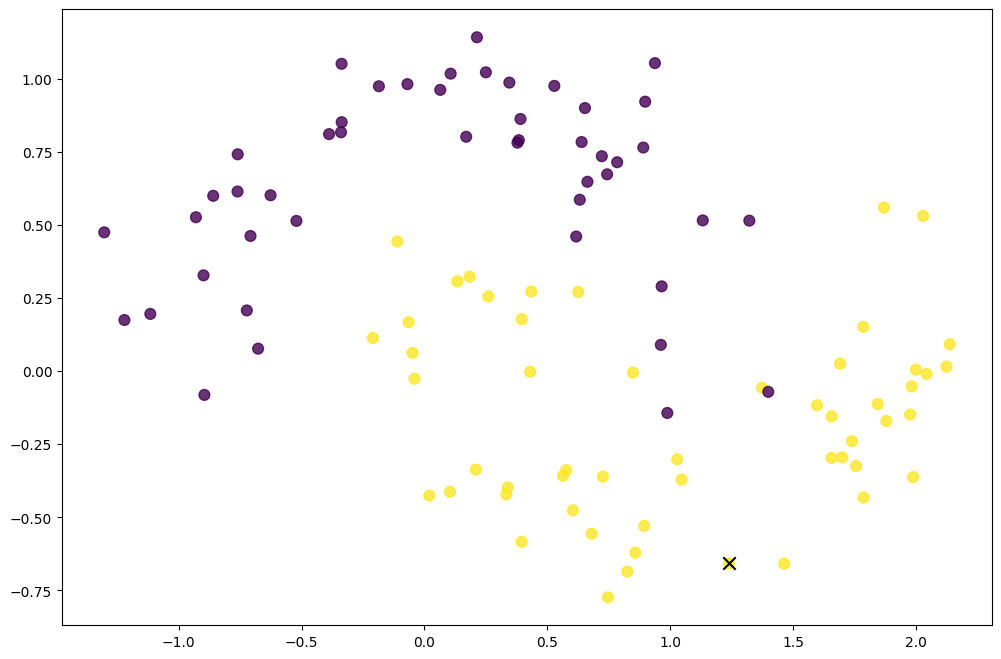

In [12]:
#Add your code here..
indx = 8

plt.scatter(
  x=z[:, 0],
  y=z[:, 1],
  c=col,
  cmap="viridis",
  alpha=0.8,
  s=60
)

plt.scatter(z[indx, 0], z[indx, 1], c='black', s=80, marker='x');


Similar to the `sklearn` random forest, to get an explanation, we need to initialise an instance of `lime.lime_tabular.LimeTabularExplainer`, which takes as main input the training data. 


**Q6.** Initialise and instance of the `LimeTabularExplainer` and set the parameter `discretize_continuous = False`; this is necessary in complex data, but not for us.

Call your initialised instance of the `LimeTabularExplainer` `explainer`.

(**Note**: the explainer doesn't use the training data to 'train', per se. If it was discretising continuous inputs, or performing similar preprocessing, it would use the training data to estimate the distribution of the data, so as to choose appropriate discretisation).

In [13]:
#Add your code here..
explainer = lime.lime_tabular.LimeTabularExplainer(train, discretize_continuous = False)


Now we can explain our point! The `explainer` instance has a `.explain_instance()` method, which we can call and pass it the point. 

**Q7.** Now pass a pointer to the prediction of class probability method of the black box model, `.predict_proba()`. As we're only passing the pointer, not the function (so that `.explain_instance()` can call the function itself) in python we leave off the `()`.

In [14]:
#Add your code here..
exp = explainer.explain_instance(z[59,:], clf.predict_proba) 


`.explain_instance` returns an explanation object. 

There a variety of methods that can be used to inspect the explanation object. For example we can call `.as_pyplot_figure` to plot a bar graph of relative weights. This isn't super informative, given we only have two features, but run it now, and see if the weights make sense to you, relative to where the point you picked is located.

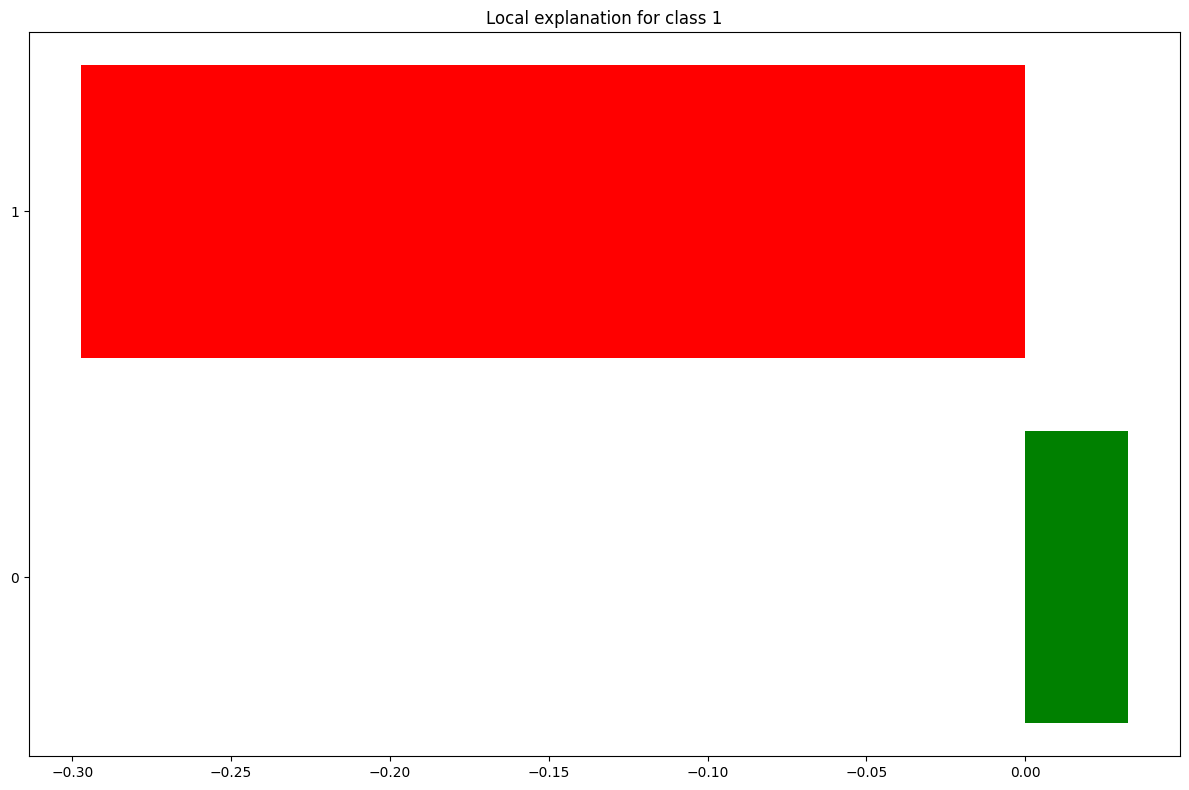

In [15]:
exp.as_pyplot_figure()
plt.tight_layout()

**Q8.** The explanation object also has a more detailed method called `.as_list()`. Try this now, to get an idea of what it returns.

In [16]:
#Add your code here..
exp.as_list()


[('1', -0.297240823465186), ('0', 0.03226435885508662)]

For the final part of this practical, we're going to use the `as_list()` method to make a pretty plot of explanations for all 100 of the points we plotted at the start. Here's some code to get you started:

In [17]:
def get_LIME_coeffs(points, explainer, clf):
    output = []
    for i, point in enumerate(points):
        exp = explainer.explain_instance(point, clf.predict_proba, num_features=2, top_labels=1)
        class_ = clf.predict([point])
        intercept = list(exp.intercept.values())[0]  # There's an irritating edge case where class_ =/= the class in the exp.
        coefs = [x[1] for x in sorted(exp.as_list(list(exp.intercept.keys())[0]), key=lambda x: x[0])]

        coefs.append(intercept)
        output.append(coefs)

    return output

**Q9.** Using this function, and `plt.quiver`, plot the explanations of each point as a vector starting at the point. 

**Questions to consider**: What do you notice? How satisfactory are the explanations? How would you develop a metric to put a number on how good the explanations are?

(**Note**: explaining 100 points will take quite a while: this is one of the downsides of perturbation methods. Because they have to sample per point explained, explaining many point can become time consuming.)

In [18]:
#Add your code here..
lime_w = np.array(get_LIME_coeffs(z, explainer, clf))
viridis = cm.get_cmap('viridis', 2)
labels = clf.predict(z)

plt.quiver(z[:,0], z[:,1], lime_w[:,0], lime_w[:,1], color=viridis(labels))
plt.show()


NameError: name 'cm' is not defined